In [1]:
import os
os.chdir("..")
from src.data.puzzle_dataset import PuzzleDataset
from src.models.gridmlp import GridMLP
from src.models.recursive_gridmlp import RecursiveGridMLP
from src.training.nng_supervised import NNGSupervisedTrainer
from src.data.criterion.categorical_abstain import AbstainLoss
from torch.utils.data import DataLoader, random_split
from notebooks.dataset_construction.parquet_dataset import ParquetReader
import matplotlib.pyplot as plt
import numpy as np
import torch
os.environ["DATA_DIR"] = "../data/"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
os.chdir("./notebooks")


Using device: cuda


In [25]:
depth = 4
def make_dataset(dataset_path, target_shape, batch_size=400):
    pq = ParquetReader(dataset_path, target_shape=target_shape)
    train_loader, test_loader, train_df, test_df = pq.create_dataloaders(batch_size=batch_size, flat=True, train_ratio=0.8)

    return train_loader, test_loader, train_df, test_df, pq


def train(train_loader, test_loader, criterion, input_shape, target_shape, num_epochs=10, trainer_class=NNGSupervisedTrainer, print_every=10):
    model = RecursiveGridMLP(input_size=input_shape, hidden_size=64, output_size=target_shape, num_layers=depth, dropout=0.1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    trainer = trainer_class(model, train_loader, test_loader, criterion, optimizer, device, epochs=num_epochs, print_every=print_every)
    trainer.train()
    return model, train_loader, test_loader

In [3]:
train_loader, test_loader, train_df, test_df, pq = make_dataset(dataset_path="../data/raw/nng_5x5.parquet", target_shape=(3, 5, 5), batch_size=1000)

In [26]:
n = 5
mlp_model, train_loader, test_loader = train(
    train_loader, test_loader, AbstainLoss(abstain_penalty=0.4), 
    n * ((n+1) // 2) * 2, n * n * 3, num_epochs=51, print_every=5)

Starting training...
Epoch 00: Train Loss=0.3772, Train Acc=0.0057 | Test Loss=0.3781, Test Acc=0.0046
Epoch 05: Train Loss=0.2326, Train Acc=0.1060 | Test Loss=0.2360, Test Acc=0.0978
Epoch 10: Train Loss=0.1895, Train Acc=0.1766 | Test Loss=0.1936, Test Acc=0.1664
Epoch 15: Train Loss=0.1588, Train Acc=0.2555 | Test Loss=0.1628, Test Acc=0.2407
Epoch 20: Train Loss=0.1364, Train Acc=0.3330 | Test Loss=0.1403, Test Acc=0.3222
Epoch 25: Train Loss=0.1201, Train Acc=0.4005 | Test Loss=0.1243, Test Acc=0.3861
Epoch 30: Train Loss=0.1093, Train Acc=0.4456 | Test Loss=0.1136, Test Acc=0.4304
Epoch 35: Train Loss=0.1000, Train Acc=0.4894 | Test Loss=0.1049, Test Acc=0.4729
Epoch 40: Train Loss=0.0927, Train Acc=0.5278 | Test Loss=0.0976, Test Acc=0.5126
Epoch 45: Train Loss=0.0867, Train Acc=0.5541 | Test Loss=0.0919, Test Acc=0.5380
Epoch 50: Train Loss=0.0823, Train Acc=0.5753 | Test Loss=0.0872, Test Acc=0.5589


In [16]:
def display_grid(ax, grid, clues=None, title='', mode='blended'):
    if grid.ndim == 3:
        _, H, W = grid.shape
    else:
        H, W = grid.shape

    if mode in ('blended', 'normalised'):
        base_colours = torch.tensor(
            [[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [0.0, 0.0, 1.0]],
            device=grid.device
        )

        if mode == 'blended':
            weights = torch.softmax(grid, dim=0)
        else:
            weights = grid / grid.sum(dim=0, keepdim=True)

        weights = weights.permute(1, 2, 0)
        img = (weights.reshape(-1, 3) @ base_colours).reshape(H, W, 3)
        img = img.detach().cpu().numpy()

    elif mode == 'rounded':
        img = (grid[0] < grid[1]).cpu().numpy()

    elif mode == 'raw':
        img = grid.detach().cpu().numpy()
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.squeeze(0)

    else:
        raise ValueError(f"Unknown mode: '{mode}'. Expected one of: blended, normalised, rounded, raw")

    # Render image
    ax.imshow(img, cmap='gray_r', interpolation='nearest')
    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)

    # Draw grid lines
    for i in range(H + 1):
        ax.axhline(i - 0.5, color='black', linewidth=1, clip_on=False)
    for j in range(W + 1):
        ax.axvline(j - 0.5, color='black', linewidth=1, clip_on=False)

    ax.axis('off')

    # Add clues
    if clues is not None:
        for i, row_clue in enumerate(clues[0]):
            clue_str = ",".join(str(int(x)) for x in row_clue if x > 0) or "0"
            ax.text(-0.6, i, clue_str, va='center', ha='right', fontsize=12)
        for j, col_clue in enumerate(clues[1]):
            clue_str = ",".join(str(int(x)) for x in col_clue if x > 0) or "0"
            ax.text(j, -0.6, clue_str, va='bottom', ha='center', fontsize=12)

    ax.set_title(title, fontsize=14)


def display_figure_grid(grids, width=None, clues=None, titles=None, figsize=(15, 15), mode='blended'):
    num_grids = len(grids)
    grid_width  = width if width is not None else int(np.ceil(np.sqrt(num_grids)))
    grid_height = int(np.ceil(num_grids / grid_width))
    _, axes = plt.subplots(grid_height, grid_width, figsize=figsize, squeeze=False)
    for i in range(num_grids):
        row = i // grid_width
        col = i % grid_width
        display_grid(
            axes[row, col],
            grids[i],
            title=titles[i] if titles is not None else '',
            clues=clues,
            mode=mode
        )
    total_cells = grid_height * grid_width
    for i in range(num_grids, total_cells):
        row = i // grid_width
        col = i % grid_width
        axes[row, col].axis('off')
        axes[row, col].set_facecolor('none')
    plt.tight_layout()
    plt.show()



In [17]:
def add_uncertainty(num):
    p_0 = 1 - num
    p_1 = num
    p_abstain = 1 - abs(num - 0.5)*2
    return torch.tensor([p_0, p_1, p_abstain], dtype=torch.float32)

def intermediate_with_uncertainty(intermediate_solutions):
    output = []
    for sol in intermediate_solutions:
        stacked = torch.stack([add_uncertainty(num) for num in sol.flatten()], dim=0)
        transposed = stacked.transpose(0, 1)
        reshaped = transposed.reshape(3, sol.shape[0], sol.shape[1])
        output.append(reshaped)
    return output

Correct solution:


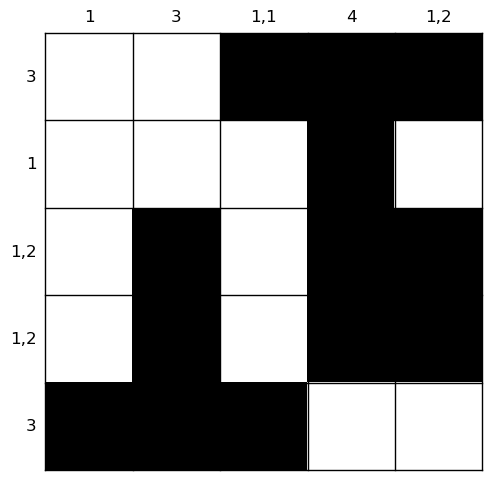

Model predictions:


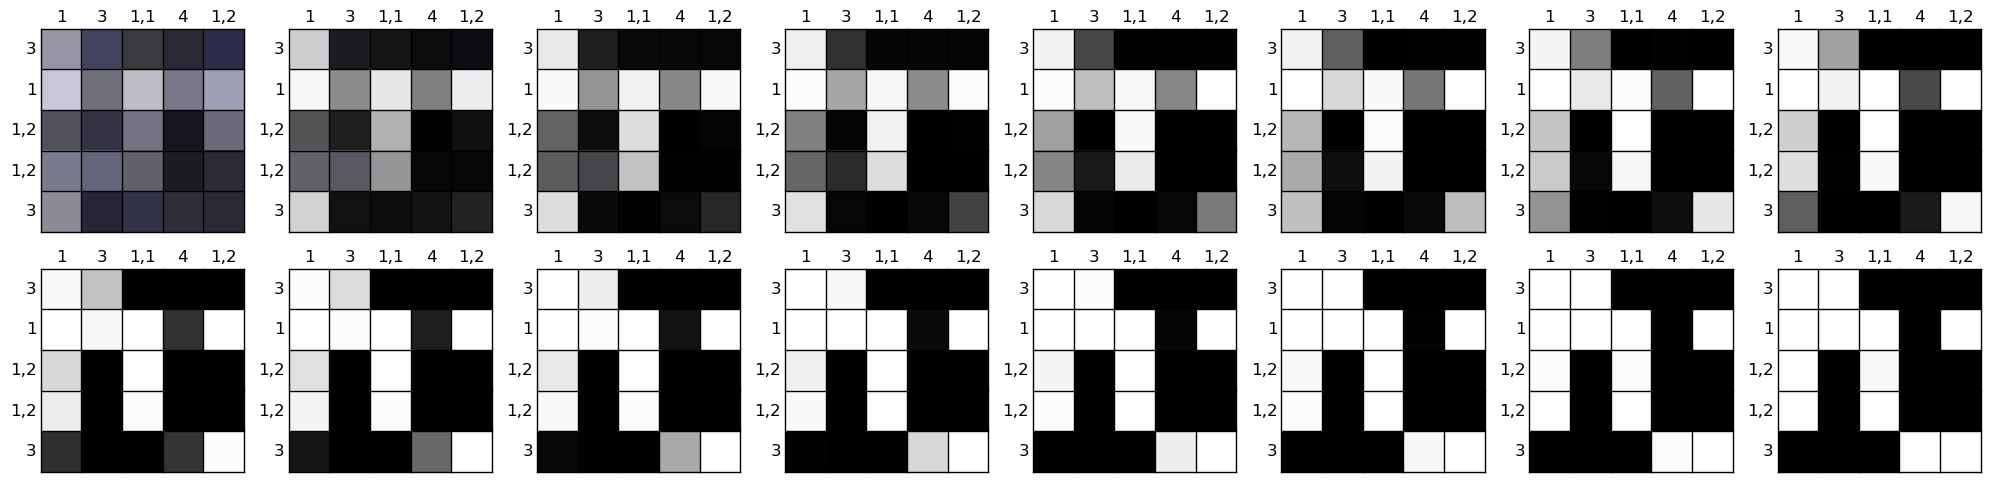

Intermediate with Uncertainty:


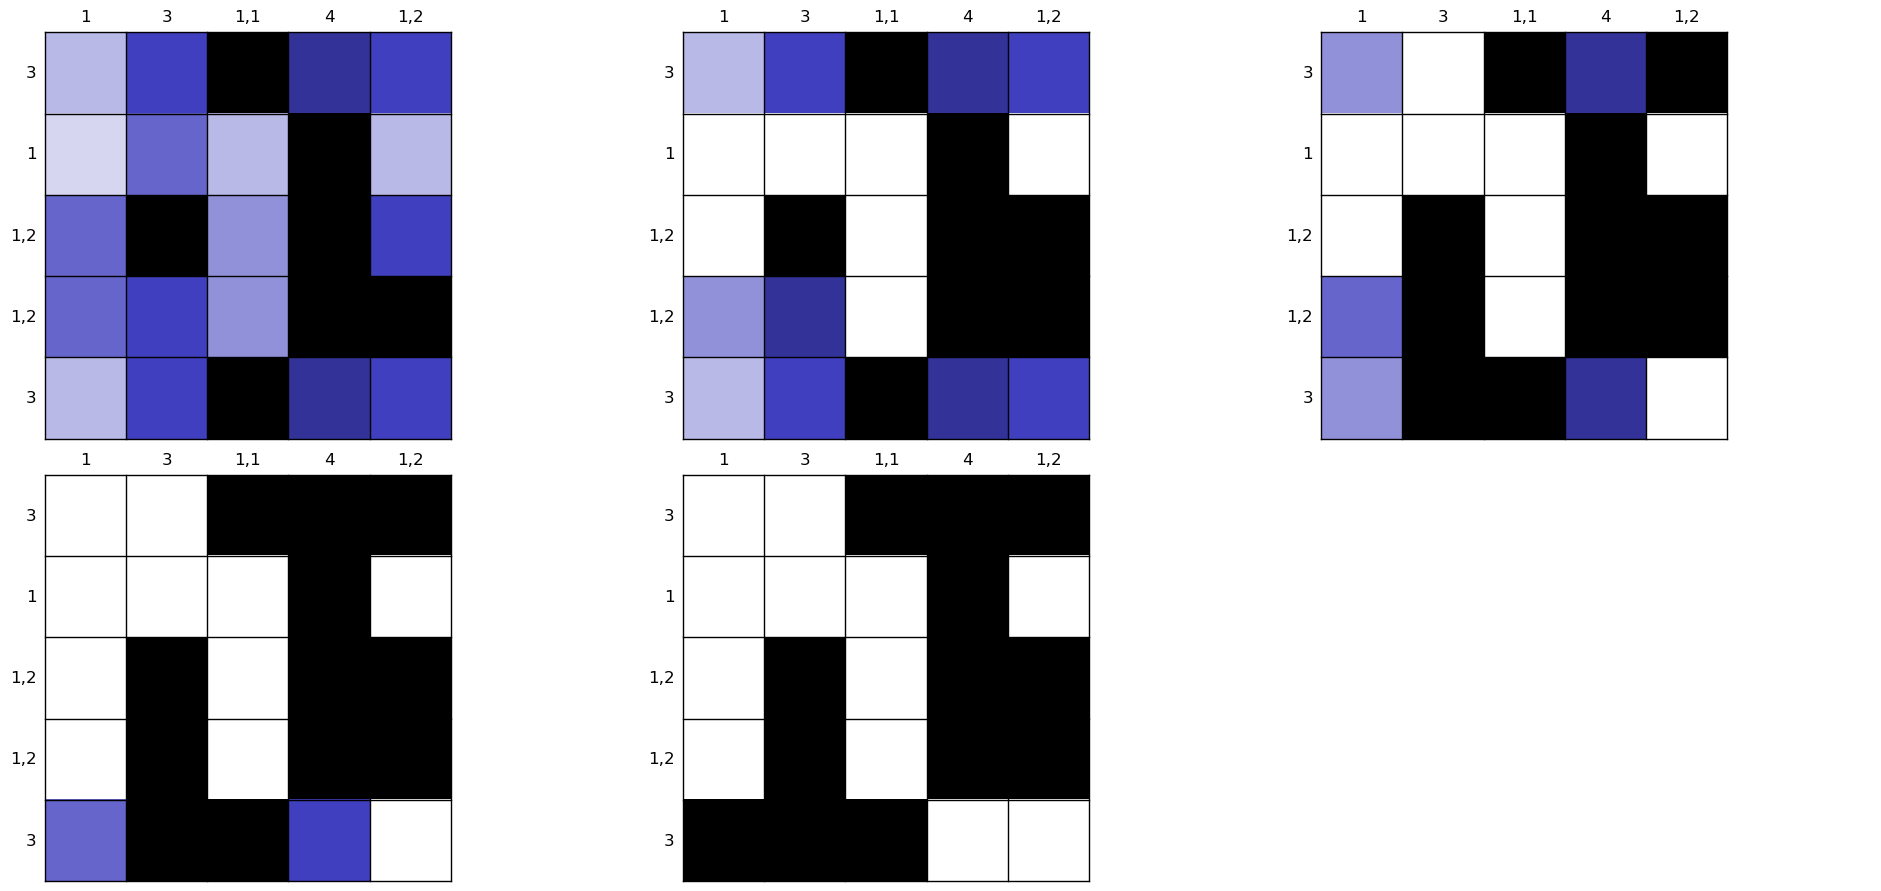

In [21]:
n = 3
pq_row = pq[n] 
target_grid = np.array(pq_row['solution'].tolist(), dtype=np.int8)
print(f"Correct solution:")
display_figure_grid([torch.tensor(target_grid)], clues=pq_row['X'], mode='raw', figsize=(5, 5))

print(f"Model predictions:")
logit_lenses = [mlp_model.forward(pq_row['X'].flatten().to(device).unsqueeze(0), layer_num=i).cpu().detach().reshape(3,5,5) for i in range(depth)]
display_figure_grid(logit_lenses, clues=(pq_row['X']), mode='blended', figsize=(20, 5), width=8)
# print(f"Intermediate solutions:")
intermediate_solutions = [torch.from_numpy(np.array(sol.tolist(), dtype=np.float32)).float() for sol in pq_row["intermediate_solutions"]]
# display_figure_grid(intermediate_solutions, clues=pq_row['X'], mode='raw', figsize=(20, 5*len(intermediate_solutions)//4 + 1), width=4)
print(f"Intermediate with Uncertainty:")
intermediate_solutions_with_uncertainty = intermediate_with_uncertainty(intermediate_solutions)
display_figure_grid(intermediate_solutions_with_uncertainty, clues=pq_row['X'], mode='normalised', figsize=(20, 5*len(intermediate_solutions_with_uncertainty)//3 + 1), width=3)


ANCOVA
- Density
- Steps
- Average runs
- requires search
- accuracy
- one step rounding
- number of search steps

In [22]:
import pandas as pd
import torch
import statsmodels.formula.api as smf

df = test_df.copy()

mlp_model.eval()
criterion = AbstainLoss(abstain_penalty=0.95)

all_correct = []
all_losses = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits = mlp_model(inputs)
        if logits.shape[1:] != labels.shape[1:]:
            logits = logits.view(labels.shape[0], -1, *labels.shape[1:])

        filtered_logits = logits[:, :2, ...]
        pred = filtered_logits.argmax(dim=1)

        matches = (pred == labels).all(dim=[1])  # Shape: [B]
        all_correct.append(matches.cpu())         # Keep as tensor, avoid .item() per batch
        for i in range(logits.shape[0]):
            loss = criterion(logits[i:i+1], labels[i:i+1])
            all_losses.append(loss.cpu())

df["correct"] = torch.cat(all_correct).numpy().astype(int)
df["cprop_steps"] = df["intermediate_methods"].apply(lambda x: len([m for m in x if m == "cprop"]))
df["requires_search"] = df["requires_search"].astype(int)
df["loss"] = torch.stack(all_losses).numpy().astype(float)
df.head()

,puzzle_id,row_clues,col_clues,solution,intermediate_solutions,intermediate_methods,grid_density,grid_height,grid_width,steps,requires_search,average_run_length,X,y,correct,cprop_steps,loss
0,34905,"[[2.0, 1.0, 0.0], [1.0, 3.0, 0.0], [2.0, 2.0, ...","[[2.0, 1.0, 0.0], [1.0, 1.0, 1.0], [2.0, 1.0, ...","[[0, 1, 1, 0, 1], [1, 0, 1, 1, 1], [1, 1, 0, 1...","[[[0.8, 1.0, 0.5, 0.14285714285714285, 0.66666...","[cprop, cprop, cprop]",0.60,5,5,3,0,1.8,"[[[tensor(2.), tensor(1.), tensor(0.)], [tenso...","[[tensor(0.), tensor(1.), tensor(1.), tensor(0...",1,3,0.000430
1,7262,"[[3.0, 1.0, 0.0], [1.0, 1.0, 0.0], [2.0, 0.0, ...","[[1.0, 2.0, 0.0], [2.0, 2.0, 0.0], [1.0, 2.0, ...","[[1, 1, 1, 0, 1], [0, 1, 0, 0, 1], [0, 0, 0, 1...","[[[1.0, 1.0, 1.0, 0.0, 1.0], [0.33333333333333...","[cprop, cprop]",0.68,5,5,2,0,1.6,"[[[tensor(3.), tensor(1.), tensor(0.)], [tenso...","[[tensor(1.), tensor(1.), tensor(1.), tensor(0...",1,2,0.000190
2,20166,"[[2.0, 0.0, 0.0], [2.0, 2.0, 0.0], [1.0, 0.0, ...","[[1.0, 1.0, 0.0], [2.0, 0.0, 0.0], [1.0, 3.0, ...","[[0, 1, 1, 0, 0], [1, 1, 0, 1, 1], [0, 0, 1, 0...","[[[0.25, 0.25, 1.0, 0.5, 0.25], [1.0, 1.0, 0.0...","[cprop, cprop, cprop]",0.48,5,5,3,0,1.7,"[[[tensor(2.), tensor(0.), tensor(0.)], [tenso...","[[tensor(0.), tensor(1.), tensor(1.), tensor(0...",1,3,0.000259
3,75162,"[[2.0, 2.0, 0.0], [1.0, 1.0, 0.0], [2.0, 1.0, ...","[[1.0, 1.0, 1.0], [5.0, 0.0, 0.0], [1.0, 0.0, ...","[[1, 1, 0, 1, 1], [0, 1, 0, 0, 1], [1, 1, 0, 1...","[[[1.0, 1.0, 0.0, 1.0, 1.0], [0.0, 1.0, 0.1111...","[cprop, cprop]",0.64,5,5,2,0,1.8,"[[[tensor(2.), tensor(2.), tensor(0.)], [tenso...","[[tensor(1.), tensor(1.), tensor(0.), tensor(1...",1,2,0.000007
4,1257,"[[2.0, 1.0, 0.0], [3.0, 1.0, 0.0], [3.0, 1.0, ...","[[5.0, 0.0, 0.0], [3.0, 1.0, 0.0], [2.0, 1.0, ...","[[1, 1, 0, 1, 0], [1, 1, 1, 0, 1], [1, 1, 1, 0...","[[[1.0, 1.0, 0.5, 0.11111111111111109, 0.8], [...","[cprop, cprop, cprop]",0.64,5,5,3,0,1.7,"[[[tensor(2.), tensor(1.), tensor(0.)], [tenso...","[[tensor(1.), tensor(1.), tensor(0.), tensor(1...",1,3,0.000261


In [23]:
# logit_model = smf.logit(
#     "correct ~ C(requires_search) + grid_density + average_run_length + cprop_steps",
#     data=df
# ).fit()

ols_model = smf.ols(
    "loss ~ C(requires_search) + grid_density + average_run_length + cprop_steps",
    data=df
).fit()

# print("\nLogistic regression (ANCOVA-equivalent for binary DV):")
# print(logit_model.summary())

print("\nOLS regression (ANCOVA-equivalent for continuous DV):")
print(ols_model.summary())

# Odds ratio for requires_search, adjusted for covariates
# print("\nOdds ratios:")
# print(pd.DataFrame({
#     "OR": logit_model.params.apply(lambda x: pow(2.718281828, x)),
#     "2.5%": logit_model.conf_int()[0].apply(lambda x: pow(2.718281828, x)),
#     "97.5%": logit_model.conf_int()[1].apply(lambda x: pow(2.718281828, x)),
# }))

print("\nCoefficients for OLS regression:")
print(pd.DataFrame({
    "Coefficient": ols_model.params,
    "2.5%": ols_model.conf_int()[0],
    "97.5%": ols_model.conf_int()[1],
}))


OLS regression (ANCOVA-equivalent for continuous DV):
                            OLS Regression Results                            
Dep. Variable:                   loss   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     355.2
Date:                Fri, 31 Jul 2026   Prob (F-statistic):          5.45e-296
Time:                        16:12:54   Log-Likelihood:                 14645.
No. Observations:               20000   AIC:                        -2.928e+04
Df Residuals:                   19995   BIC:                        -2.924e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

Raw accuracy by requires_search:
                     mean  count
requires_search                 
0                0.940330  19809
1                0.581152    191

Group sizes:
requires_search
0    19809
1      191
Name: count, dtype: int64

Covariate means by group:
                 cprop_steps  grid_density  average_run_length
requires_search                                               
0                   3.497198      0.523217            1.548427
1                   7.874346      0.427853            1.469110

Covariate distributions (describe):
requires_search                      0           1
cprop_steps        count  19809.000000  191.000000
                   mean       3.497198    7.874346
                   std        1.293314    1.533802
                   min        1.000000    5.000000
                   25%        3.000000    7.000000
                   50%        3.000000    8.000000
                   75%        4.000000    9.000000
                   max       12.0

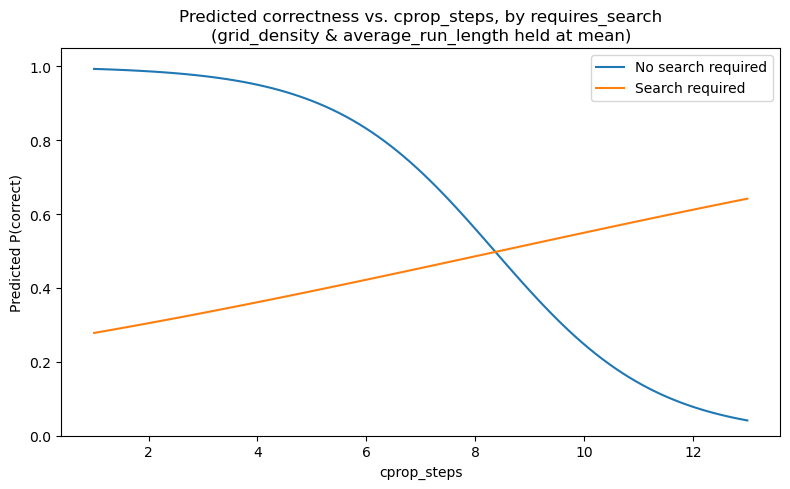

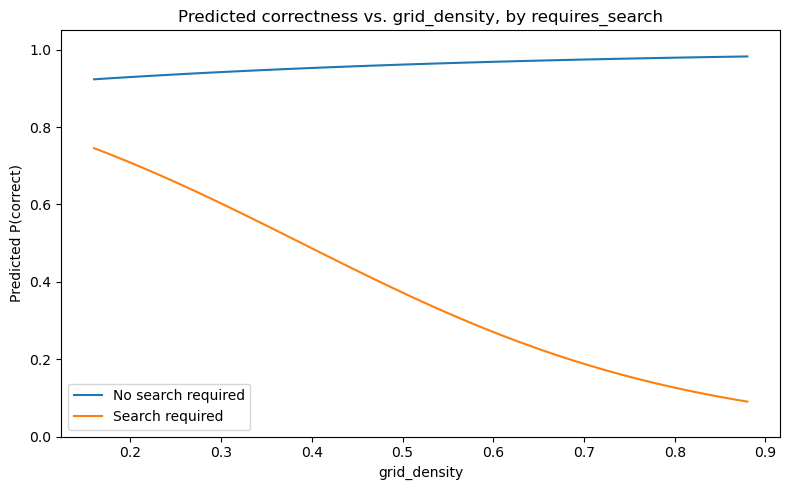

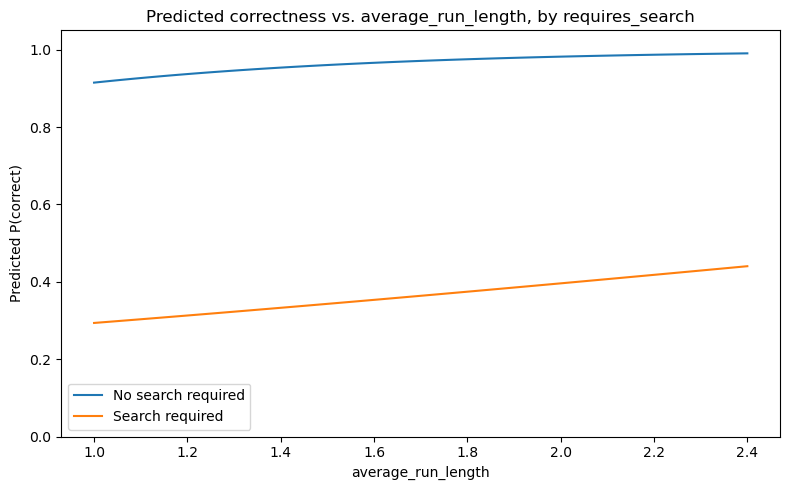

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# -------------------------------------------------
# 0. Sanity checks BEFORE trusting any model
# -------------------------------------------------

# 0a. Raw accuracy by group — no covariates, no model, just the truth
print("Raw accuracy by requires_search:")
print(df.groupby("requires_search")["correct"].agg(["mean", "count"]))

# 0b. Are the two groups balanced in size? Big imbalance can distort ORs
print("\nGroup sizes:")
print(df["requires_search"].value_counts())

# 0c. Do covariates differ systematically between groups?
# If requires_search puzzles are just "easier" on steps/density/run_length,
# that's a confound, not a real search effect.
print("\nCovariate means by group:")
print(df.groupby("requires_search")[["cprop_steps", "grid_density", "average_run_length"]].mean())
print("\nCovariate distributions (describe):")
print(df.groupby("requires_search")[["cprop_steps", "grid_density", "average_run_length"]].describe().T)

# 0d. Check for duplicated puzzles / leakage: are search and non-search
# puzzles drawn from disjoint step ranges, e.g. all requires_search=1 having steps=1?
print("\nCprop_steps range by group:")
print(df.groupby("requires_search")["cprop_steps"].agg(["min", "max", "nunique"]))

# -------------------------------------------------
# 1. Fit interaction logit model
# -------------------------------------------------
interaction_logit = smf.logit(
    "correct ~ C(requires_search) * (cprop_steps + grid_density + average_run_length)",
    data=df
).fit()
print(interaction_logit.summary())

# -------------------------------------------------
# 2. Predicted probability of correctness vs. cprop_steps, split by requires_search
#    (hold grid_density and average_run_length at their sample means)
# -------------------------------------------------
grid_density_mean = df["grid_density"].mean()
run_length_mean = df["average_run_length"].mean()

cprop_steps_range = np.linspace(df["cprop_steps"].min(), df["cprop_steps"].max(), 100)

pred_frames = []
for rs in [0, 1]:
    grid = pd.DataFrame({
        "cprop_steps": cprop_steps_range,
        "grid_density": grid_density_mean,
        "average_run_length": run_length_mean,
        "requires_search": rs,
    })
    grid["pred_prob"] = interaction_logit.predict(grid)
    pred_frames.append(grid)

pred_df = pd.concat(pred_frames)


plt.figure(figsize=(8, 5))
for rs, label, color in [(0, "No search required", "tab:blue"), (1, "Search required", "tab:orange")]:
    sub = pred_df[pred_df["requires_search"] == rs]
    plt.plot(sub["cprop_steps"], sub["pred_prob"], label=label, color=color)

plt.xlabel("cprop_steps")
plt.ylabel("Predicted P(correct)")
plt.title("Predicted correctness vs. cprop_steps, by requires_search\n(grid_density & average_run_length held at mean)")
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("interaction_plot_cprop_steps.png", dpi=150)
plt.show()

# -------------------------------------------------
# 3. Same plot but vs grid_density, and vs average_run_length
# -------------------------------------------------
def plot_vs(covariate, others):
    cov_range = np.linspace(df[covariate].min(), df[covariate].max(), 100)
    frames = []
    for rs in [0, 1]:
        grid = pd.DataFrame({covariate: cov_range, "requires_search": rs, **others})
        grid["pred_prob"] = interaction_logit.predict(grid)
        frames.append(grid)
    pdf = pd.concat(frames)

    plt.figure(figsize=(8, 5))
    for rs, label, color in [(0, "No search required", "tab:blue"), (1, "Search required", "tab:orange")]:
        sub = pdf[pdf["requires_search"] == rs]
        plt.plot(sub[covariate], sub["pred_prob"], label=label, color=color)
    plt.xlabel(covariate)
    plt.ylabel("Predicted P(correct)")
    plt.title(f"Predicted correctness vs. {covariate}, by requires_search")
    plt.legend()
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(f"interaction_plot_{covariate}.png", dpi=150)
    plt.show()

plot_vs("grid_density", {"cprop_steps": df["cprop_steps"].mean(), "average_run_length": run_length_mean})
plot_vs("average_run_length", {"cprop_steps": df["cprop_steps"].mean(), "grid_density": grid_density_mean})

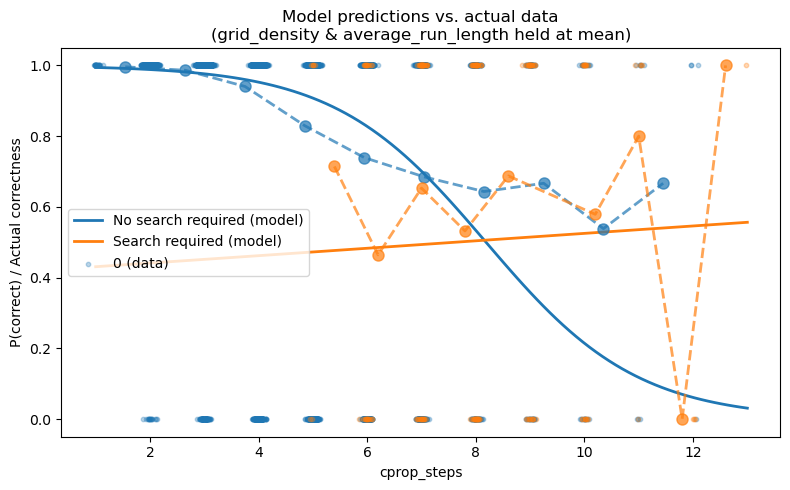

In [14]:
plt.figure(figsize=(8, 5))

# Plot the smooth prediction curves (as before)
for rs, label, color in [(0, "No search required", "tab:blue"), (1, "Search required", "tab:orange")]:
    sub = pred_df[pred_df["requires_search"] == rs]
    plt.plot(sub["cprop_steps"], sub["pred_prob"], label=f"{label} (model)", color=color, linewidth=2)

# Overlay actual data points with jitter for visibility
for rs, color in [(0, "tab:blue"), (1, "tab:orange")]:
    subset = df[df["requires_search"] == rs]
    # Add small random jitter to avoid overplotting
    jitter = np.random.normal(0, 0.05, size=len(subset))
    plt.scatter(
        subset["cprop_steps"] + jitter, 
        subset["correct"],  # Binary: 0 or 1
        alpha=0.3, 
        s=10, 
        color=color,
        label=f"{rs} (data)" if rs == 0 else None
    )

# Optional: Add binned averages to show real trend
for rs, color in [(0, "tab:blue"), (1, "tab:orange")]:
    subset = df[df["requires_search"] == rs]
    bins = pd.cut(subset["cprop_steps"], bins=10)
    bin_means = subset.groupby(bins)["correct"].mean()
    bin_centers = [interval.mid for interval in bin_means.index]
    plt.plot(bin_centers, bin_means.values, 'o--', color=color, markersize=8, linewidth=2, alpha=0.7)

plt.xlabel("cprop_steps")
plt.ylabel("P(correct) / Actual correctness")
plt.title("Model predictions vs. actual data\n(grid_density & average_run_length held at mean)")
plt.legend(loc='best')
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("interaction_plot_with_data.png", dpi=150)
plt.show()

In [45]:
# 1. Check distribution of cprop_steps
print("Distribution of cprop_steps:")
print(df["cprop_steps"].value_counts().sort_index())

# 2. Check if there are enough data points in each region
print("\nData density by requires_search and cprop_steps:")
print(pd.crosstab(df["requires_search"], pd.cut(df["cprop_steps"], bins=5)))

# 3. Compare model predictions to actual binned averages
df["pred_prob"] = interaction_logit.predict(df)
df["cprop_bin"] = pd.cut(df["cprop_steps"], bins=10)

comparison = df.groupby(["requires_search", "cprop_bin"]).agg(
    actual_mean=("correct", "mean"),
    pred_mean=("pred_prob", "mean"),
    count=("correct", "count")
).reset_index()

print("\nModel fit check (actual vs predicted by bin):")
print(comparison)

Distribution of cprop_steps:
cprop_steps
1        58
2     12286
3     23082
4     13720
5      5972
6      2635
7      1237
8       562
9       256
10      128
11       41
12       17
13        5
14        1
Name: count, dtype: int64

Data density by requires_search and cprop_steps:
cprop_steps      (0.987, 3.6]  (3.6, 6.2]  (6.2, 8.8]  (8.8, 11.4]  \
requires_search                                                      
0                       35426       22220        1485          256   
1                           0         107         314          169   

cprop_steps      (11.4, 14.0]  
requires_search                
0                          15  
1                           8  

Model fit check (actual vs predicted by bin):
    requires_search     cprop_bin  actual_mean  pred_mean  count
0                 0  (0.987, 2.3]     0.968892   0.955708  12344
1                 0    (2.3, 3.6]     0.918898   0.900764  23082
2                 0    (3.6, 4.9]     0.759402   0.800194  13720